Customer Churn Intelligence — Business Insights & Strategy Notebook

Purpose: Convert analytics → insights → decisions → business value
1. Setup

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/processed/segmented_data.csv")
pred_df = pd.read_csv("../data/processed/churn_predictions.csv")

df.head()


,Age,Gender,Country,City,Membership_Years,Login_Frequency,Session_Duration_Avg,Pages_Per_Session,Cart_Abandonment_Rate,Wishlist_Items,...,Lifetime_Value,Credit_Balance,Churned,Signup_Quarter,engagement_index,risk_score,value_score,segment,segment_confidence,segment_label
0,43.0,Male,France,Marseille,2.9,14.0,27.4,6.0,50.6,3.0,...,953.33,2278.0,0,Q1,16.32,27.58,498.309,0,0.938446,Needs Attention
1,36.0,Male,UK,Manchester,1.6,15.0,42.7,10.3,37.7,1.0,...,1067.47,3028.0,0,Q4,27.68,35.85,556.075,1,0.572155,At Risk
2,45.0,Female,Canada,Vancouver,2.9,10.0,24.8,1.6,70.9,1.0,...,1289.75,2317.0,0,Q4,12.80,27.67,680.709,0,0.905463,Needs Attention
3,56.0,Female,USA,New York,2.6,10.0,38.4,14.8,41.7,9.0,...,2340.92,2674.0,0,Q1,38.10,28.09,1204.426,2,0.893265,Loyal
4,35.0,Male,India,Delhi,3.1,29.0,51.4,8.4,19.1,9.0,...,3041.29,5354.0,0,Q4,41.94,28.93,1558.655,2,0.931030,Loyal


## Problem Statement

Customer churn directly impacts revenue, growth, and long-term business sustainability.
The goal of this project is to:
- Identify churn drivers
- Predict churn risk
- Segment customers by value and risk
- Quantify revenue at risk
- Design data-driven retention strategies

This project transforms raw customer data into actionable business intelligence.


## Data Overview

Dataset Characteristics:
- 50,000 customers
- Multi-country coverage
- Full customer journey lifecycle
- Behavioral, engagement, financial, and service features
- Binary churn target variable


In [2]:
df.shape


(50000, 31)

In [3]:
churn_rate = df["Churned"].mean()
churn_rate


np.float64(0.289)

### Interpretation:
This represents the overall churn rate across the platform and serves as the baseline business risk.


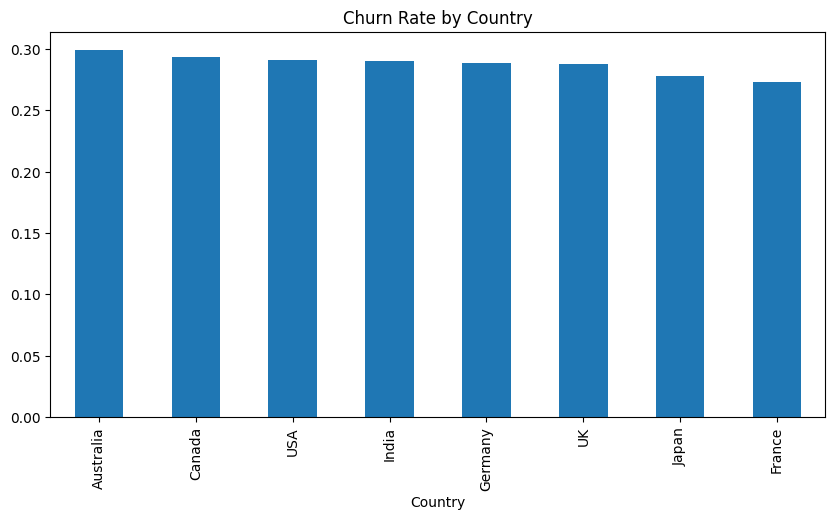

In [4]:
country_churn = df.groupby("Country")["Churned"].mean().sort_values(ascending=False)

plt.figure(figsize=(10,5))
country_churn.plot(kind="bar", title="Churn Rate by Country")
plt.show()


### Insight:
Certain regions show significantly higher churn, indicating market-specific behavioral or experience issues.


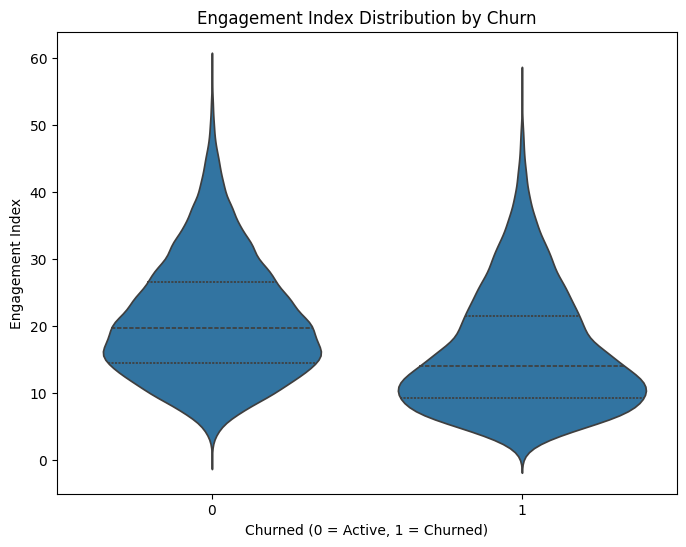

In [5]:
plt.figure(figsize=(8,6))
sns.violinplot(x="Churned", y="engagement_index", data=df, inner="quartile")
plt.title("Engagement Index Distribution by Churn")
plt.xlabel("Churned (0 = Active, 1 = Churned)")
plt.ylabel("Engagement Index")
plt.show()


### Insight:
Low engagement is a strong early-warning signal for churn.


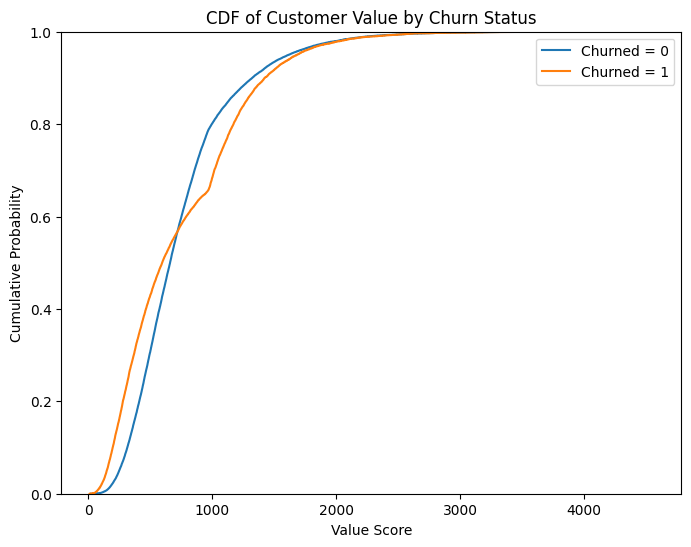

In [6]:
plt.figure(figsize=(8,6))

for label, grp in df.groupby("Churned"):
    sns.ecdfplot(grp["value_score"], label=f"Churned = {label}")

plt.title("CDF of Customer Value by Churn Status")
plt.xlabel("Value Score")
plt.ylabel("Cumulative Probability")
plt.legend()
plt.show()


### Insight:
Not all churn has equal impact — high-value churners represent disproportionate revenue risk.


### Top 10 Drivers of Customer Churn

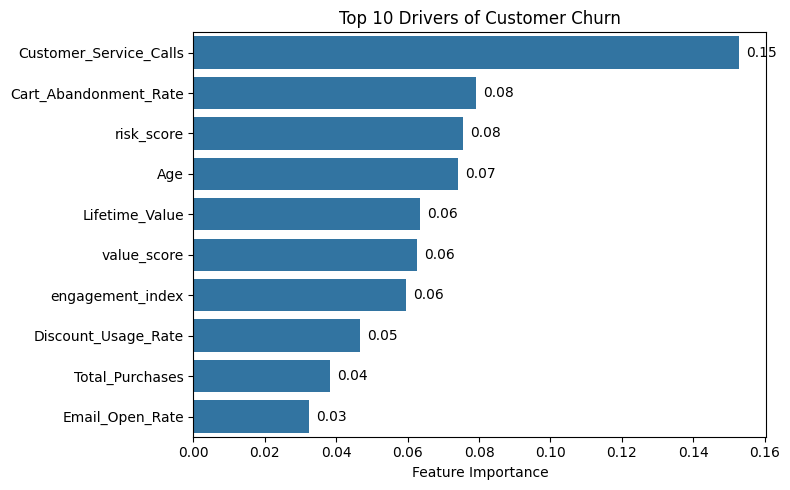

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

 
feature_importance = pd.read_csv("../results/feature_importance.csv", index_col=0)

top_features = (
    feature_importance
    .sort_values(by=feature_importance.columns[0], ascending=False)
    .head(10)
    .reset_index()
)

top_features.columns = ["Feature", "Importance"]

plt.figure(figsize=(8,5))
ax = sns.barplot(
    x="Importance",
    y="Feature",
    data=top_features
)

plt.title("Top 10 Drivers of Customer Churn")
plt.xlabel("Feature Importance")
plt.ylabel("")

# Value labels (VERY nice touch)
for p in ax.patches:
    ax.text(
        p.get_width() + 0.002,
        p.get_y() + p.get_height()/2,
        f"{p.get_width():.2f}",
        va="center"
    )

plt.tight_layout()
plt.show()


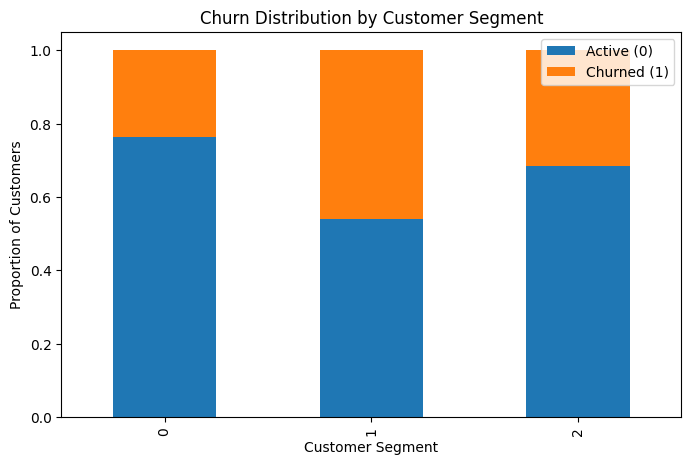

In [ ]:
segment_counts = (
    df.groupby(["segment", "Churned"])
    .size()
    .reset_index(name="count")
)

segment_pivot = segment_counts.pivot(
    index="segment", columns="Churned", values="count"
)

segment_pct = segment_pivot.div(segment_pivot.sum(axis=1), axis=0)

segment_pct.plot(
    kind="bar",
    stacked=True,
    figsize=(8,5)
)

plt.title("Churn Distribution by Customer Segment")
plt.ylabel("Proportion of Customers")
plt.xlabel("Customer Segment")
plt.legend(["Active (0)", "Churned (1)"])
plt.show()


### Insight:
Customer segments show distinct churn behaviors, enabling targeted retention strategies.


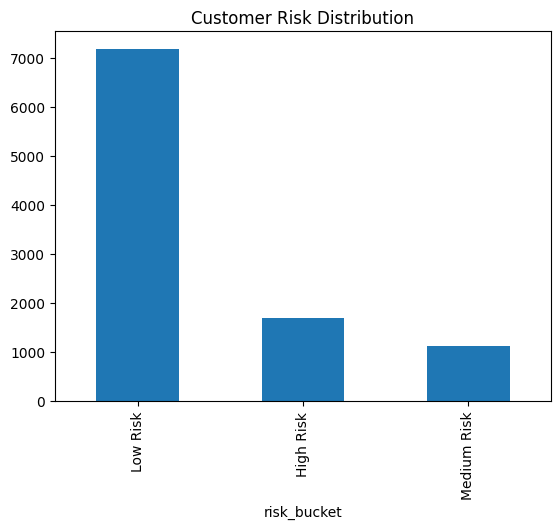

In [ ]:
risk_dist = pred_df["risk_bucket"].value_counts()

risk_dist.plot(kind="bar", title="Customer Risk Distribution")
plt.show()


### Insight:
Customers can be operationally categorized into high, medium, and low risk groups for prioritized action.


In [ ]:
risk_df = pd.read_csv("../data/processed/churn_predictions.csv")

high_risk_count = (risk_df["risk_bucket"]=="High Risk").sum()
high_risk_count


np.int64(1688)

### Interpretation:
High-risk customers represent immediate revenue threat and should be prioritized for intervention.


## Early Warning Signals

The following indicators strongly correlate with churn:

- Declining login frequency
- Reduced session duration
- Increased cart abandonment
- Rising customer service calls
- Long inactivity periods
- Low engagement scores
- Reduced purchase frequency


## Retention Strategy Framework

### High Risk + High Value
- VIP retention offers
- Dedicated support
- Personalized engagement
- Loyalty rewards

### High Risk + Low Value
- Automated retention flows
- Cost-effective campaigns
- Discount optimization

### Medium Risk
- Engagement nurturing
- Content personalization
- Experience optimization

### Low Risk
- Loyalty reinforcement
- Cross-sell and upsell


## Decision Intelligence System

This system enables proactive business decisions:

- Predict churn risk before it happens
- Prioritize customers by value impact
- Allocate retention budgets efficiently
- Optimize engagement strategies
- Reduce reactive churn management
- Enable data-driven growth strategy


## Business Impact Projection

Expected outcomes:
- Reduced churn rate
- Improved customer lifetime value
- Higher retention efficiency
- Optimized retention spending
- Increased revenue stability
- Better customer experience


## Executive Summary

This project demonstrates how data analytics and machine learning can be used to transform customer data into business intelligence.
By integrating predictive modeling, segmentation, and behavioral analysis, the platform enables proactive churn management, strategic retention planning, and revenue protection.
